### Imports

In [141]:
from IPython import display

import cv2
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import tensorflow_probability as tfp
import time

import os
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [142]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 8
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Definitions

In [143]:
train_size = 60000
batch_size = 32
test_size = 10000
# Path to your images folder
# IMAGES_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification/train"
IMAGES_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/dividing_rf"
INPUT_SHAPE = 200

### Functions

In [144]:
def preprocess_images(images):
  images = images.reshape((images.shape[0], INPUT_SHAPE, INPUT_SHAPE, 1)) / 255.
  return np.where(images > .5, 1.0, 0.0).astype('float32')

### Get train data

In [145]:
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split

# List all image file paths
image_files = [os.path.join(IMAGES_PATH, image) for image in os.listdir(IMAGES_PATH)]

# Split file paths into train and test
train_files, test_files = train_test_split(image_files, test_size=0.2, random_state=42)

def load_and_preprocess_image_tf(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])  # Explicitly set shape for resizing
    # image = tf.image.resize(image, [INPUT_SHAPE, INPUT_SHAPE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def make_dataset(file_list, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    ds = ds.map(load_and_preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

batch_size = 32
train_dataset = make_dataset(train_files, batch_size)
test_dataset = make_dataset(test_files, batch_size)

### Definition of the model

In [146]:
kernel_size = (4,4)
filter = 32

class CVAE(tf.keras.Model):
  """Convolutional variational autoencoder."""

  def __init__(self, latent_dim):
    super(CVAE, self).__init__()
    self.latent_dim = latent_dim

    # --- ENCODER ---
    self.encoder = tf.keras.Sequential(
        [
            tf.keras.layers.InputLayer(input_shape=(INPUT_SHAPE, INPUT_SHAPE, 1)),
            tf.keras.layers.Conv2D(filters=32, kernel_size=5, strides=(2, 2), activation=tf.nn.leaky_relu, padding='same'), # 200x200 -> 100x100
            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Conv2D(filters=64, kernel_size=3, strides=(2, 2), activation=tf.nn.leaky_relu, padding='same'), # 100x100 -> 50x50
            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Conv2D(filters=128, kernel_size=3, strides=(2, 2), activation=tf.nn.leaky_relu, padding='same'), # 50x50 -> 25x25
            tf.keras.layers.BatchNormalization(),
            
            tf.keras.layers.Conv2D(filters=256, kernel_size=3, strides=(2, 2), activation=tf.nn.leaky_relu, padding='same'), 
            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ]
    )

    # --- DECODER ---
    self.decoder = tf.keras.Sequential(
        [
          tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
          tf.keras.layers.Dense(units=13*13*256, activation=tf.nn.relu), 
          tf.keras.layers.Reshape(target_shape=(13, 13, 256)),
          tf.keras.layers.BatchNormalization(),

          tf.keras.layers.Conv2DTranspose(filters=128, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu), # 13x13 -> 26x26
          tf.keras.layers.BatchNormalization(),

          tf.keras.layers.Conv2DTranspose(filters=64, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),   # 26x26 -> 52x52
          tf.keras.layers.BatchNormalization(),

          tf.keras.layers.Conv2DTranspose(filters=32, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),   # 52x52 -> 104x104
          tf.keras.layers.BatchNormalization(),
          
          tf.keras.layers.Conv2DTranspose(filters=16, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),   # 104x104 -> 208x208
          tf.keras.layers.BatchNormalization(),

          tf.keras.layers.Conv2DTranspose(filters=1, kernel_size=3, strides=1, padding='same', activation=None), # 208x208 -> 208x208
          
          tf.keras.layers.Cropping2D(((4,4),(4,4))), 
        ]
    )

  @tf.function
  def sample(self, eps=None):
    if eps is None:
      eps = tf.random.normal(shape=(100, self.latent_dim))
    return self.decode(eps, apply_sigmoid=True)

  def encode(self, x):
    mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
    return mean, logvar

  def reparameterize(self, mean, logvar):
    eps = tf.random.normal(shape=mean.shape)
    return eps * tf.exp(logvar * .5) + mean

  def decode(self, z, apply_sigmoid=False):
    logits = self.decoder(z)
    if apply_sigmoid:
      probs = tf.sigmoid(logits)
      return probs
    return logits

### Loss definitions

Funcion de perdida total:
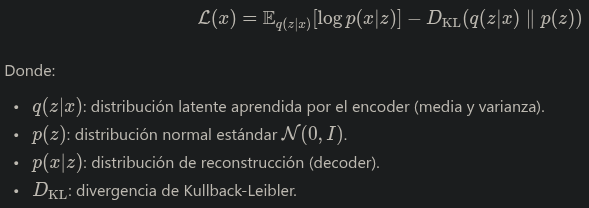


Referencia 1
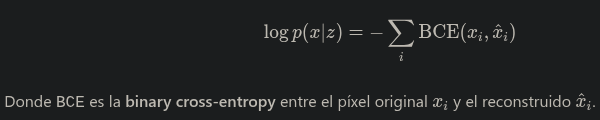


Referencia 2
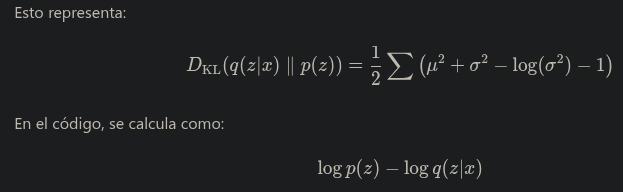

logpz: la probabilidad de que z venga de una normal estándar.
logqz_x: la probabilidad de que z venga de la distribución aprendida por el encoder.

Referencia 3:
log_normal_pdf calcula logaritmo de la densidad de probabilidad de una distribución normal multivariada. Se usa para:
Fórmula:
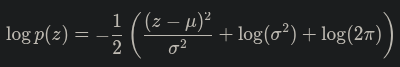


In [147]:
#Referencia 3
def log_normal_pdf(sample, mean, logvar, raxis=1):
  log2pi = tf.math.log(2. * np.pi)
  return tf.reduce_sum(
      -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
      axis=raxis)
#logvar es log(σ²), por eso se usa tf.exp(-logvar) para obtener 1/σ².

class CustomLoss(tf.keras.losses.Loss):
    def __init__(self, y, z, name="custom_loss"):
        super().__init__(name=name)
        # Weights
        self.y = y
        self.z = z

        # MAE
        self.mae_loss_fn = tf.keras.losses.MeanAbsoluteError()

    # SSIM loss
    def ssim_loss(self, y_true, y_pred):
        ssim = (1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))) / 2
        return ssim

    def call(self, y_true, y_pred):
        mae_loss = self.mae_loss_fn(y_true, y_pred)
        ssim = self.ssim_loss(y_true, y_pred)
        return self.y * mae_loss + self.z * ssim

# Instancia de CustomLoss
custom_loss_fn = CustomLoss(y=0.17, z=0.83)

def compute_loss(model, x, beta):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)

    # Referencia 1: diferencia entre la reconstrucción y la entrada original usando CustomLoss
    x_logit = model.decode(z)
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    reconstruction_loss = tf.reduce_sum(cross_ent, axis=[1, 2, 3])

    # Uso la custom loss
    # x_logit = model.decode(z, apply_sigmoid=True)
    # reconstruction_loss = custom_loss_fn(x, x_logit)

    # Referencia 2: divergencia KL entre la distribución latente y una normal estándar
    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)
    kl_divergence = logqz_x - logpz

    # VAE normal
    # total_loss = tf.reduce_mean(reconstruction_loss + kl_divergence)

    # beta-VAE
    total_loss = tf.reduce_mean(reconstruction_loss + beta * kl_divergence)

    return total_loss, tf.reduce_mean(reconstruction_loss), tf.reduce_mean(kl_divergence)

@tf.function
def train_step(model, x, optimizer, beta):
  """Executes one training step and returns the loss.

  This function computes the loss and gradients, and uses the latter to
  update the model's parameters.
  """
  with tf.GradientTape() as tape:
    loss = compute_loss(model, x, beta)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

In [148]:

# set the dimensionality of the latent space to a plane for visualization later
latent_dim = 64
num_examples_to_generate = 16

# keeping the random vector constant for generation (prediction) so
# it will be easier to see the improvement.
random_vector_for_generation = tf.random.normal(shape=[num_examples_to_generate, latent_dim])
model = CVAE(latent_dim)

/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [149]:
def generate_and_save_images(model, epoch, test_sample):
  mean, logvar = model.encode(test_sample)
  z = model.reparameterize(mean, logvar)
  predictions = model.sample(z)
  fig = plt.figure(figsize=(6, 6))

  for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(predictions[i, :, :, 0], cmap='gray')
    plt.axis('off')

  # tight_layout minimizes the overlap between 2 sub-plots
  # plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

In [150]:
# Pick a sample of the test set for generating output images
assert batch_size >= num_examples_to_generate
for test_batch in test_dataset.take(1):
  test_sample = test_batch[0:num_examples_to_generate, :, :, :]

Epoch: 500, Test set ELBO: -26687.740234375, Test set Resconstrucion loss: 26359.212890625, Test set kl: 4.380328178405762, beta: 75, time elapse for current epoch: 1.569164514541626


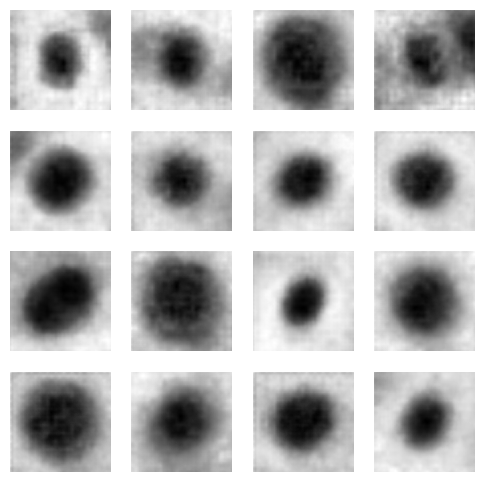

In [ ]:
optimizer = tf.keras.optimizers.Adam(1e-5)
epochs = 200
beta = 75
BETA_FINAL = 75

elbo_values = []
reconstruction_losses = []
kl_divergences = []

generate_and_save_images(model, 0, test_sample)

for epoch in range(1, epochs + 1):
  start_time = time.time()
  beta_for_step = min(BETA_FINAL, BETA_FINAL * (epoch / epochs))
  for train_x in train_dataset:
      train_step(model, train_x, optimizer, beta)
  end_time = time.time()

  loss = tf.keras.metrics.Mean()
  reconstruction_loss = tf.keras.metrics.Mean()
  kl_divergence = tf.keras.metrics.Mean()
  
  for test_x in test_dataset:
      total_loss, rec_loss, kl_div = compute_loss(model, test_x, beta)
      loss(total_loss)
      reconstruction_loss(rec_loss)
      kl_divergence(kl_div)
  
  elbo = -loss.result()
  elbo_values.append(elbo.numpy())
  reconstruction_losses.append(reconstruction_loss.result().numpy())
  kl_divergences.append(kl_divergence.result().numpy())

  display.clear_output(wait=False)
  print(f'Epoch: {epoch}, Test set ELBO: {elbo}, Test set Resconstrucion loss: {reconstruction_loss.result()}, Test set kl: {kl_divergence.result()}, beta: {beta_for_step}, time elapse for current epoch: {end_time - start_time}')
  generate_and_save_images(model, epoch, test_sample)


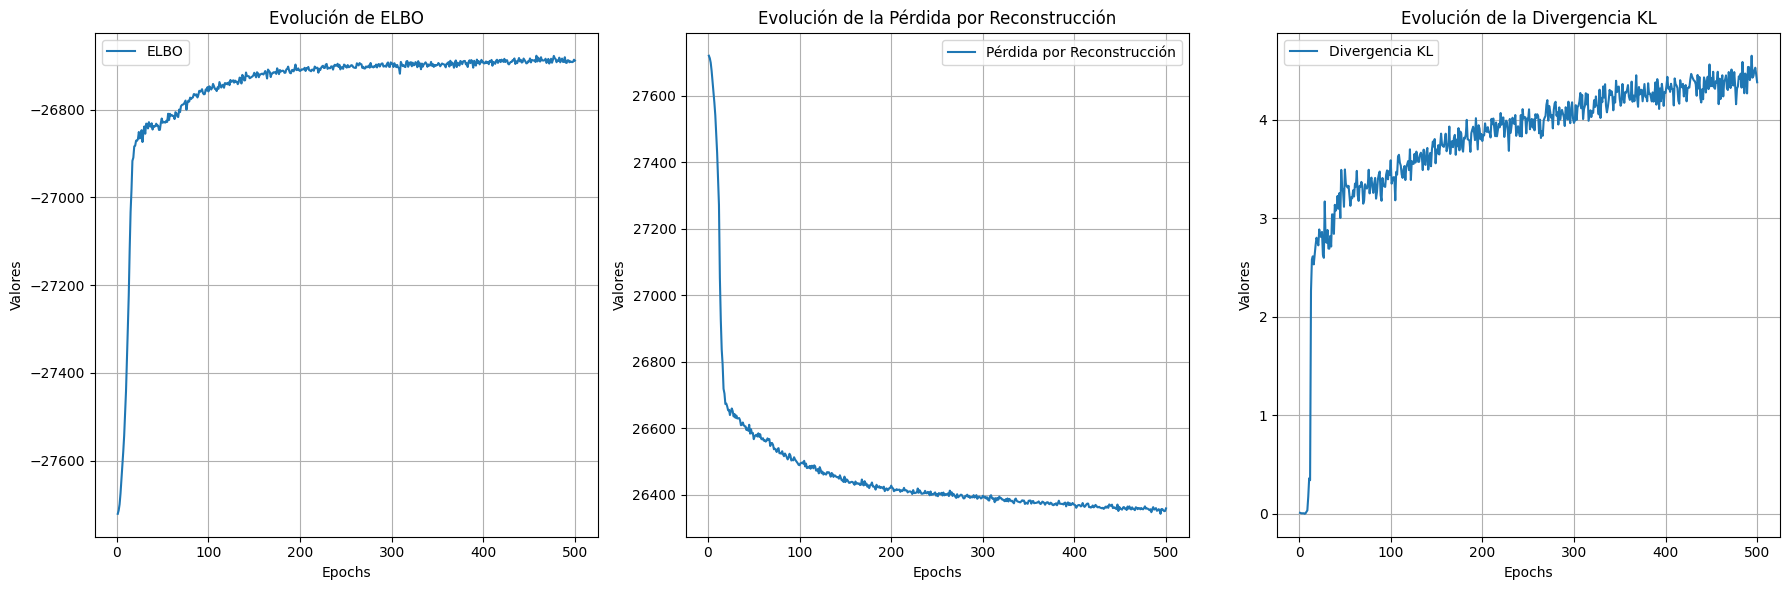

In [152]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: ELBO
axs[0].plot(epochs_range, elbo_values, label='ELBO')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Valores')
axs[0].set_title('Evolución de ELBO')
axs[0].legend()
axs[0].grid(True)

# Subplot 2: Pérdida por Reconstrucción
axs[1].plot(epochs_range, reconstruction_losses, label='Pérdida por Reconstrucción')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Valores')
axs[1].set_title('Evolución de la Pérdida por Reconstrucción')
axs[1].legend()
axs[1].grid(True)

# Subplot 3: Divergencia KL
axs[2].plot(epochs_range, kl_divergences, label='Divergencia KL')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel('Valores')
axs[2].set_title('Evolución de la Divergencia KL')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [153]:
# def display_image(epoch_no):
#   return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

In [154]:
# plt.imshow(display_image(epoch))
# plt.axis('off')  # Display images

In [155]:
# anim_file = 'cvae.gif'

# with imageio.get_writer(anim_file, mode='I') as writer:
#   filenames = glob.glob('image*.png')
#   filenames = sorted(filenames)
#   for filename in filenames:
#     image = imageio.imread(filename)
#     writer.append_data(image)
#   image = imageio.imread(filename)
#   writer.append_data(image)

In [156]:
# import tensorflow_docs.vis.embed as embed
# embed.embed_file(anim_file)

Collected 1000 latent vectors of dimension 64
Applying t-SNE...
t-SNE finished.
Shape of 2D latent space: (1000, 2)


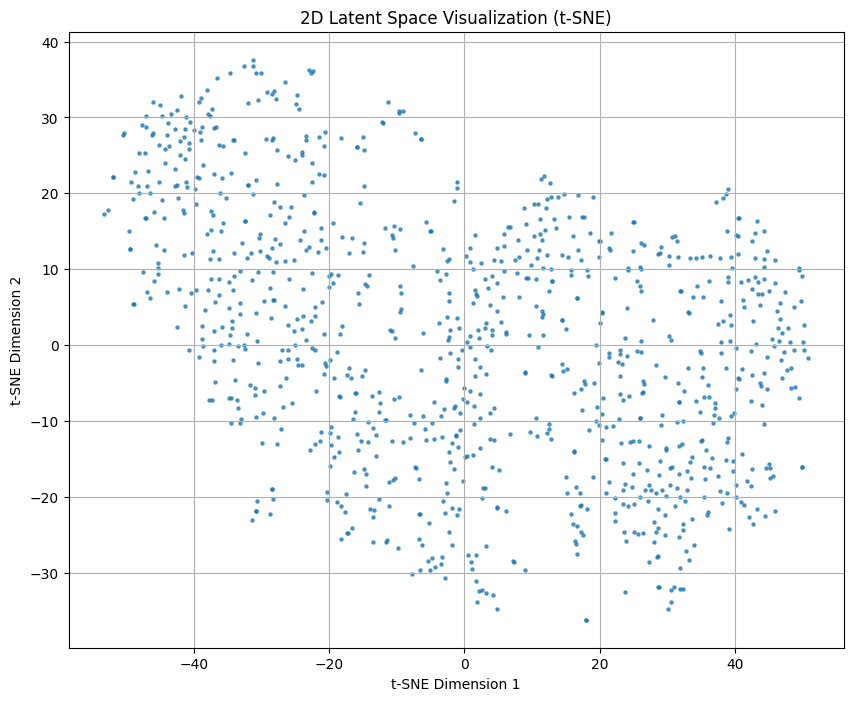

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from umap import UMAP # A more direct import


BATCH_SIZE = 32
# For UMAP, you'll need to install it: pip install umap-learn
# import umap

# Assuming your trained `model` (CVAE instance) is available and `test_dataset` is available

# 1. Collect latent vectors from the dataset
# It's good practice to use a smaller, representative subset if your dataset is huge
# For example, take the first N batches from train_dataset or test_dataset
num_images_to_plot = 1000 # Adjust based on your dataset size and computational resources

latent_vectors = []
original_images = [] # Optionally store original images for context

for i, batch in enumerate(train_dataset.take(num_images_to_plot // BATCH_SIZE + 1)):
    # Encode the batch to get mu and log_var
    mu, log_var = model.encode(batch)
    latent_vectors.append(mu.numpy())
    original_images.append(batch.numpy()) # Keep original images for later visualization

    if (i + 1) * BATCH_SIZE >= num_images_to_plot:
        break

latent_vectors = np.vstack(latent_vectors)[:num_images_to_plot]
original_images = np.vstack(original_images)[:num_images_to_plot]

print(f"Collected {latent_vectors.shape[0]} latent vectors of dimension {latent_vectors.shape[1]}")

# Initialize t-SNE
# perplexity: Balance attention between local and global aspects of your data.
#             Typically between 5 and 50.
# n_components: 2 for 2D plot, 3 for 3D plot.
# n_iter: Number of iterations (more iterations = better embedding, but slower).
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=2000)

print("Applying t-SNE...")
latent_2d_tsne = tsne.fit_transform(latent_vectors)
print("t-SNE finished.")
print("Shape of 2D latent space:", latent_2d_tsne.shape)

plt.figure(figsize=(10, 8))
plt.scatter(latent_2d_tsne[:, 0], latent_2d_tsne[:, 1], s=5, alpha=0.7)
plt.title('2D Latent Space Visualization (t-SNE)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

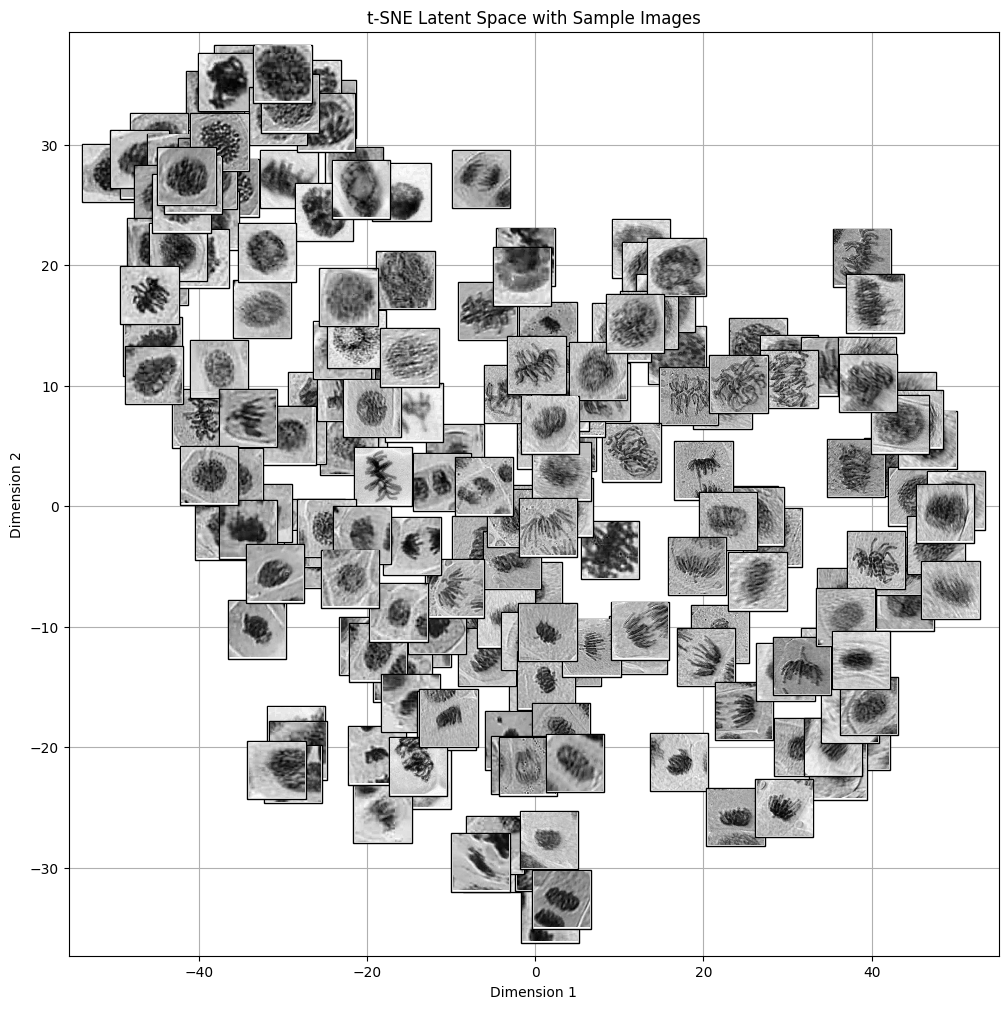

In [158]:
def plot_latent_space_with_images(latent_coords, images, title="Latent Space Visualization"):
    """
    Plots a 2D latent space scatter plot and overlays corresponding images.
    Not suitable for very large numbers of points.
    """
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.scatter(latent_coords[:, 0], latent_coords[:, 1], s=2, alpha=0.5, color='blue') # Basic scatter layer

    # Randomly select a subset of images to display
    display_indices = np.random.choice(len(images), min(200, len(images)), replace=False) # Display max 50 images

    for i in display_indices:
        x_coord, y_coord = latent_coords[i]
        img = images[i].squeeze() # Remove channel dimension (1, H, W, 1) -> (H, W)

        # Create an annotation box for the image
        imagebox = OffsetImage(img, zoom=0.2, cmap='gray') # Adjust zoom as needed
        ab = AnnotationBbox(imagebox, (x_coord, y_coord),
                            xybox=(0., 0.),
                            xycoords='data',
                            boxcoords="offset points",
                            pad=0.1,
                            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2"))
        ax.add_artist(ab)

    ax.set_title(title)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    plt.show()

# You'll need `OffsetImage` and `AnnotationBbox` from matplotlib.offsetbox
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Call this function with a small subset
# Example: Using the first 50 latent vectors and their corresponding original images
plot_latent_space_with_images(latent_2d_tsne[:200], original_images[:200], 
                              title="t-SNE Latent Space with Sample Images")

Collected 1000 latent vectors of dimension 64
Applying UMAP...


/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP finished.
Shape of 2D latent space: (1000, 2)


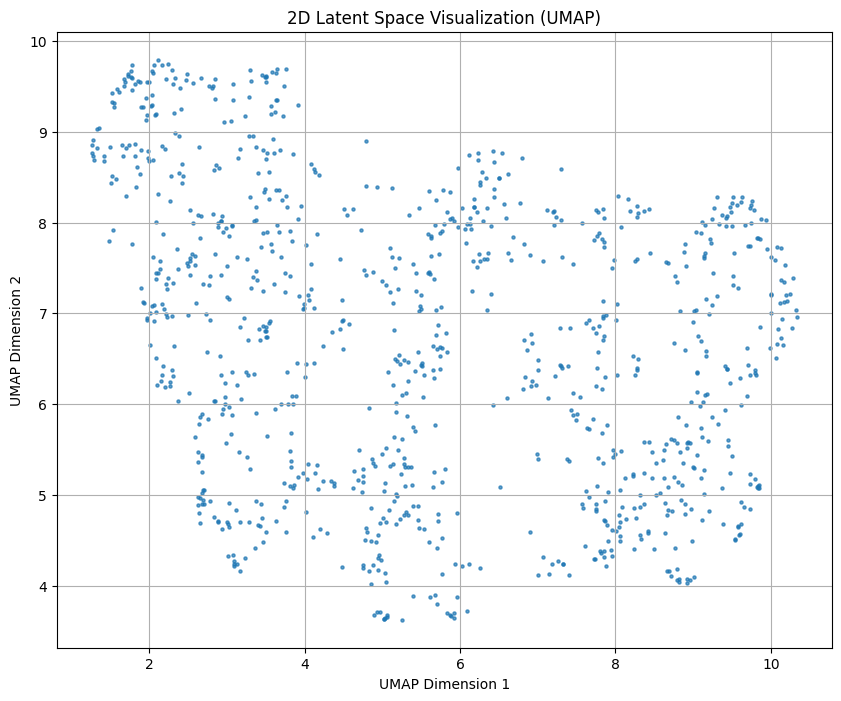

In [159]:
import numpy as np
import matplotlib.pyplot as plt
# import umap # Make sure you have installed it: pip install umap-learn
from umap import UMAP # A more direct import

# Assuming your trained `model` (CVAE instance) and `train_dataset` are available
BATCH_SIZE = 32
num_images_to_plot = 1000

# 1. Collect latent vectors from the dataset (this part remains the same)
latent_vectors = []
for i, batch in enumerate(train_dataset.take(num_images_to_plot // BATCH_SIZE + 1)):
    mu, log_var = model.encode(batch)
    latent_vectors.append(mu.numpy())
    if (i + 1) * BATCH_SIZE >= num_images_to_plot:
        break
latent_vectors = np.vstack(latent_vectors)[:num_images_to_plot]

print(f"Collected {latent_vectors.shape[0]} latent vectors of dimension {latent_vectors.shape[1]}")

# --- Start of Changes ---

# 2. Initialize UMAP
# n_neighbors: Controls how UMAP balances local versus global structure.
#              Think of it as the number of nearby points UMAP will look at for each point.
#              Smaller values focus on local structure, larger values on global structure.
#              A value between 5 and 50 is common.
# min_dist:    Controls how tightly UMAP is allowed to pack points together.
#              Lower values create more compact clusters.
# n_components: 2 for a 2D plot.
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

print("Applying UMAP...")
latent_2d_umap = reducer.fit_transform(latent_vectors)
print("UMAP finished.")
print("Shape of 2D latent space:", latent_2d_umap.shape)

# 3. Plot the results
plt.figure(figsize=(10, 8))
plt.scatter(latent_2d_umap[:, 0], latent_2d_umap[:, 1], s=5, alpha=0.7)
plt.title('2D Latent Space Visualization (UMAP)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True)
plt.show()

# --- End of Changes ---

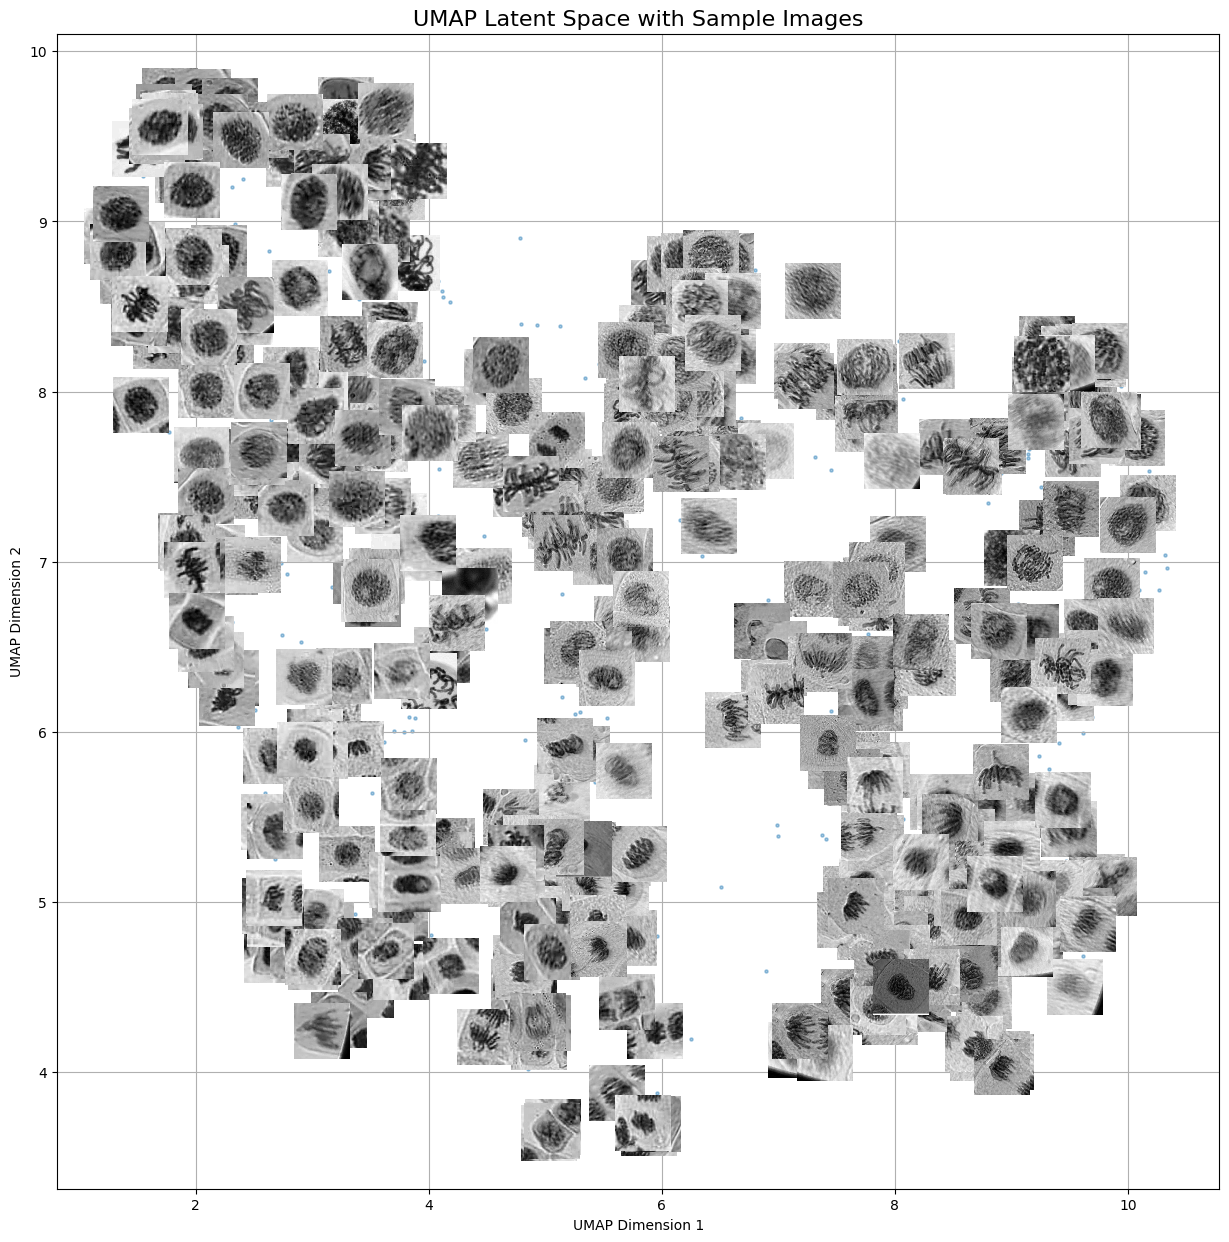

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# --- Assume previous code has been run ---
# You should have these variables from the UMAP script:
# - latent_2d_umap: The 2D coordinates from UMAP.
# - original_images: The original images corresponding to the latent vectors.
#   (Make sure you stored them in the first step!)

# Let's re-create original_images for a self-contained example
# (In your full script, you would already have this variable)
num_images_to_plot = 1000
original_images = []
for i, batch in enumerate(train_dataset.take(num_images_to_plot // BATCH_SIZE + 1)):
    original_images.append(batch.numpy())
    if (i + 1) * BATCH_SIZE >= num_images_to_plot:
        break
original_images = np.vstack(original_images)[:num_images_to_plot]

# --- Function Definition (with a minor improvement) ---
def plot_latent_space_with_images(
    latent_coords, 
    images, 
    title="Latent Space Visualization",
    num_to_display=400, # How many images to show
    zoom=0.2 # Image zoom level
):
    """
    Plots a 2D latent space scatter plot and overlays a random subset of corresponding images.
    """
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Basic scatter plot layer
    ax.scatter(latent_coords[:, 0], latent_coords[:, 1], s=5, alpha=0.4)

    # Randomly select a subset of images to display
    indices = np.random.choice(len(images), num_to_display, replace=False)

    for i in indices:
        x_coord, y_coord = latent_coords[i]
        img = images[i].squeeze() 

        # Create an annotation box for the image without an arrow
        # This makes the plot less cluttered
        imagebox = OffsetImage(img, zoom=zoom, cmap='gray')
        imagebox.image.axes = ax

        ab = AnnotationBbox(
            imagebox, (x_coord, y_coord),
            frameon=False,
            pad=0.0,
        )
        ax.add_artist(ab)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.grid(True)
    plt.show()


# --- MODIFIED FUNCTION CALL ---

# Call the function using your UMAP results
plot_latent_space_with_images(
    latent_2d_umap, 
    original_images, 
    title="UMAP Latent Space with Sample Images"
)